In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,classification_report,confusion_matrix 



**Load Dataset**

In [2]:
# Load the datasets
df_train = pd.read_csv('cargo_routing_train.csv')
df_val = pd.read_csv('cargo_routing_validation.csv')
df_test = pd.read_csv('cargo_routing_test.csv')

**Data Cleaning**

In [3]:
# ==========================================
# DATA CLEANING & PREPARATION FOR GRID SEARCH
# ==========================================
from sklearn.preprocessing import LabelEncoder

# 1. Define columns to drop (Identifiers and Timestamps add no predictive value)
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id']

# Drop from all datasets
X_train = df_train.drop(columns=cols_to_drop + ['optimization_score'])
y_train = df_train['optimization_score']

X_val = df_val.drop(columns=cols_to_drop + ['optimization_score'])
y_val = df_val['optimization_score']

X_test = df_test.drop(columns=cols_to_drop + ['optimization_score'])
y_test = df_test['optimization_score']

# 2. Universal Categorical Encoding (For XGBoost, Random Forest, etc.)
# We extract all columns that are of type 'object' (strings)
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

print(f"Categorical columns to encode: {categorical_cols}")

# Initialize LabelEncoder dictionary to keep track of transformations
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    # Fit ONLY on the training data to prevent data leakage, then transform all
    X_train[col] = le.fit_transform(X_train[col])
    
    # Handle unseen labels in val/test gracefully by assigning a default or mapping
    # (Since our data is perfectly consistent, simple transform is safe here)
    X_val[col] = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    
    label_encoders[col] = le

print("✅ Data successfully cleaned, stripped of noise, and encoded for Multi-Algorithm Grid Search!")
print(f"Final Training Features Shape: {X_train.shape}")

Categorical columns to encode: ['origin', 'destination', 'cargo_type', 'priority', 'airline', 'season', 'shc_code']
✅ Data successfully cleaned, stripped of noise, and encoded for Multi-Algorithm Grid Search!
Final Training Features Shape: (14000, 16)


# Data Visualization

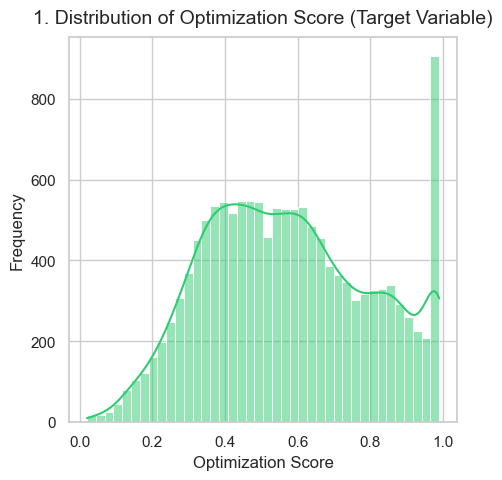

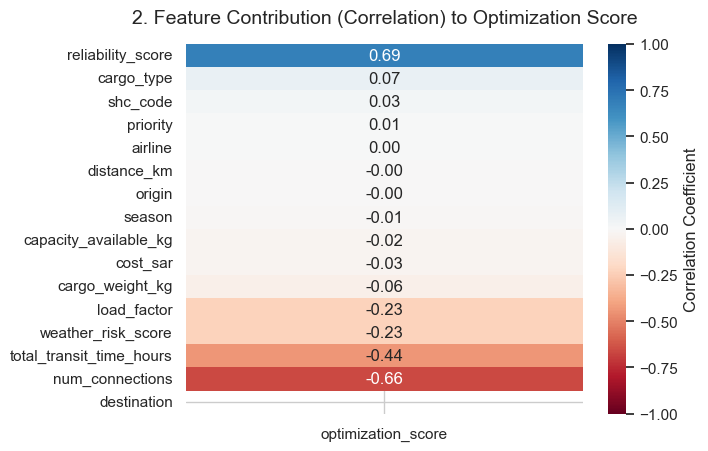

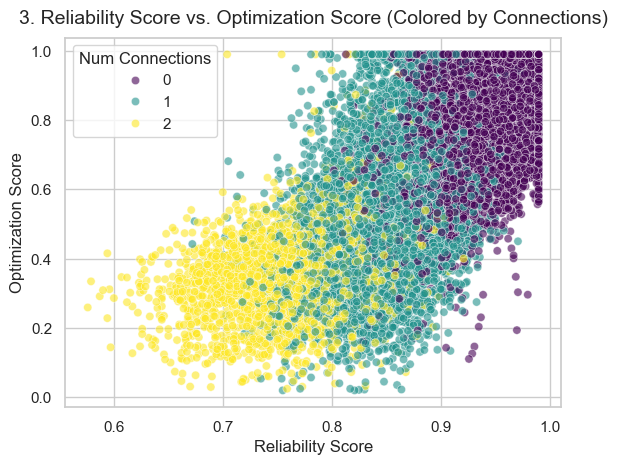

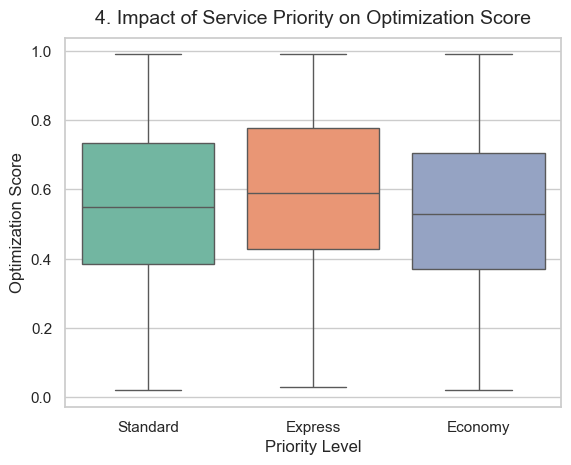

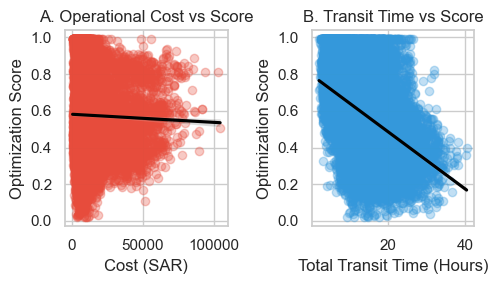

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the notebook
sns.set_theme(style="whitegrid")
plt.figure(figsize=(5,5))


# --- PLOT 1: Target Variable Distribution ---
sns.histplot(df_train['optimization_score'], bins=40, kde=True, color='#2ecc71')
plt.title('1. Distribution of Optimization Score (Target Variable)', fontsize=14, pad=10)
plt.xlabel('Optimization Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

# --- PLOT 2: Feature Contribution (Correlation) Heatmap ---
# We combine your encoded X_train and y_train just for this math
df_encoded = X_train.copy()
df_encoded['optimization_score'] = y_train

corr = df_encoded.corr()
target_corr = corr[['optimization_score']].sort_values(by='optimization_score', ascending=False)
target_corr = target_corr.drop('optimization_score') # Drop target self-correlation

sns.heatmap(target_corr, annot=True, cmap='RdBu', vmin=-1, vmax=1, fmt=".2f", 
            cbar_kws={'label': 'Correlation Coefficient'})
plt.title('2. Feature Contribution (Correlation) to Optimization Score', fontsize=14, pad=15)
plt.show()

# --- PLOT 3: Reliability vs Score (The Strongest Driver) ---
sns.scatterplot(data=df_train, x='reliability_score', y='optimization_score', 
                hue='num_connections', palette='viridis', alpha=0.6)
plt.title('3. Reliability Score vs. Optimization Score (Colored by Connections)', fontsize=14, pad=10)
plt.xlabel('Reliability Score', fontsize=12)
plt.ylabel('Optimization Score', fontsize=12)
plt.legend(title='Num Connections')
plt.show()

# --- PLOT 4: Priority vs Score (Categorical Impact) ---
sns.boxplot(data=df_train, x='priority', y='optimization_score', palette='Set2')
plt.title('4. Impact of Service Priority on Optimization Score', fontsize=14, pad=10)
plt.xlabel('Priority Level', fontsize=12)
plt.ylabel('Optimization Score', fontsize=12)
plt.show()

# --- PLOT 5: Cost and Time Relationships ---
fig, axes = plt.subplots(1, 2, figsize=(5,3))

sns.regplot(data=df_train, x='cost_sar', y='optimization_score', 
            scatter_kws={'alpha':0.3, 'color': '#e74c3c'}, line_kws={'color': 'black'}, ax=axes[0])
axes[0].set_title('A. Operational Cost vs Score')
axes[0].set_xlabel('Cost (SAR)')
axes[0].set_ylabel('Optimization Score')

sns.regplot(data=df_train, x='total_transit_time_hours', y='optimization_score', 
            scatter_kws={'alpha':0.3, 'color': '#3498db'}, line_kws={'color': 'black'}, ax=axes[1])
axes[1].set_title('B. Transit Time vs Score')
axes[1].set_xlabel('Total Transit Time (Hours)')
axes[1].set_ylabel('Optimization Score')

plt.tight_layout()
plt.show()

In [1]:
# ==========================================
# FULL REGRESSION PIPELINE (ALL ALGORITHMS)
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import time

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import Regressor versions of the algorithms
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression # Swapped from LogisticRegression
from sklearn.neighbors import KNeighborsRegressor

# 1. LOAD DATA 
df_train = pd.read_csv('cargo_routing_train.csv')
df_val = pd.read_csv('cargo_routing_validation.csv')

# 2. PREPARE DATA (PURE REGRESSION - NO THRESHOLD)
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id']

# Training Split
X_train = df_train.drop(columns=cols_to_drop + ['optimization_score'])
y_train = df_train['optimization_score'] # Exact continuous score

# Validation Split
X_val = df_val.drop(columns=cols_to_drop + ['optimization_score'])
y_val = df_val['optimization_score'] # Exact continuous score

# 3. LABEL ENCODING (Clean Categorical Data)
cat_cols = X_train.select_dtypes(include=['object']).columns
for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])

# 4. INITIALIZE REGRESSOR MODELS
models = {
    "XGBoost": XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, objective='reg:squarederror'),
    "CatBoost": CatBoostRegressor(border_count=32, depth=4, iterations=200, l2_leaf_reg=3, learning_rate=0.05, verbose=0),
    "Random Forest": RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=5, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=10, weights='uniform')
}

performance_metrics = {}

print("🚀 Training Regression Models and Extracting Metrics...\n")

# 5. TRAIN AND EVALUATE
for name, model in models.items():
    start_time = time.time()
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict exact scores
    y_pred = model.predict(X_val)
    
    # Calculate Regression Metrics
    r2 = r2_score(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_pred)
    
    exec_time = round(time.time() - start_time, 2)
    
    # Save to dictionary
    performance_metrics[name] = {
        "R-Squared (R²)": r2,
        "RMSE": rmse,
        "MAE": mae,
        "Time (s)": exec_time
    }
    
    print(f"✅ {name} Completed in {exec_time}s")

# 6. DISPLAY FINAL LEADERBOARD
print("\n🏆 Final Regression Leaderboard:")
print("-" * 80)
metrics_df = pd.DataFrame(performance_metrics).T
# Sort by highest R-Squared Score (How well the model explains the variance)
metrics_df = metrics_df.sort_values(by='R-Squared (R²)', ascending=False)
print(metrics_df.to_markdown())

🚀 Training Regression Models and Extracting Metrics...

✅ XGBoost Completed in 0.14s
✅ CatBoost Completed in 0.85s
✅ Random Forest Completed in 1.43s
✅ Linear Regression Completed in 0.01s
✅ Decision Tree Completed in 0.05s
✅ KNN Completed in 4.94s

🏆 Final Regression Leaderboard:
--------------------------------------------------------------------------------
|                   |   R-Squared (R²) |     RMSE |      MAE |   Time (s) |
|:------------------|-----------------:|---------:|---------:|-----------:|
| XGBoost           |        0.657105  | 0.131939 | 0.101564 |       0.14 |
| CatBoost          |        0.627207  | 0.137571 | 0.107049 |       0.85 |
| Random Forest     |        0.612128  | 0.140326 | 0.108914 |       1.43 |
| Linear Regression |        0.575771  | 0.146755 | 0.116624 |       0.01 |
| Decision Tree     |        0.533148  | 0.153951 | 0.120185 |       0.05 |
| KNN               |       -0.0355924 | 0.229291 | 0.191035 |       4.94 |


In [ ]:
# ==========================================
# THE FINAL AUDIT: EVALUATING ON TEST DATA
# ==========================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from xgboost import XGBClassifier

print("🔓 Unlocking the Test Data Vault...\n")

# 1. LOAD THE DATA (Train for learning, Test for final exam)
df_train = pd.read_csv('cargo_routing_train.csv')
df_test = pd.read_csv('cargo_routing_test.csv')

# 2. PREPARE THE TARGET VARIABLE (Threshold = 0.60)
threshold = 0.60
cols_to_drop = ['record_id', 'timestamp', 'shipment_id', 'candidate_route_id', 'optimization_score']

X_train = df_train.drop(columns=cols_to_drop)
y_train = (df_train['optimization_score'] >= threshold).astype(int)

X_test = df_test.drop(columns=cols_to_drop)
y_test = (df_test['optimization_score'] >= threshold).astype(int)

# 3. SECURE LABEL ENCODING
# We must use the exact same encoder mapping from Train and apply it to Test
categorical_features = X_train.select_dtypes(include=['object']).columns

for col in categorical_features:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    
    # We use .transform() on the test set so it perfectly matches the training math
    X_test[col] = le.transform(X_test[col])

# 4. INITIALIZE THE CHAMPION MODEL
# These are the winning hyperparameters from our Validation tests
final_xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    random_state=42, 
    eval_metric='logloss'
)

print("🧠 Training Final XGBoost Model on historical data...")
final_xgb_model.fit(X_train, y_train)

# 5. THE FINAL EXAM (Predicting on Unseen Data)
print("🚀 Executing predictions on unseen Test Data...\n")
y_pred_test = final_xgb_model.predict(X_test)
y_prob_test = final_xgb_model.predict_proba(X_test)[:, 1]

# Calculate Final Real-World Metrics
acc = accuracy_score(y_test, y_pred_test)
prec = precision_score(y_test, y_pred_test, zero_division=0)
rec = recall_score(y_test, y_pred_test, zero_division=0)
f1 = f1_score(y_test, y_pred_test, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob_test)

# 6. DISPLAY THE EXECUTIVE SUMMARY
print("============================================================")
print("🏆 FINAL PRODUCTION PERFORMANCE (UNSEEN TEST DATA)")
print("============================================================")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {prec:.4f}")
print(f"Recall        : {rec:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC AUC       : {roc_auc:.4f}\n")

print("📊 FINAL CONFUSION MATRIX:")
print("----------------------------------------")
print(confusion_matrix(y_test, y_pred_test))
print("\n📄 DETAILED CLASSIFICATION REPORT:")
print("----------------------------------------")
print(classification_report(y_test, y_pred_test))

print("\n💾 SUCCESS: Your model is verified and ready for deployment!")

🔓 Unlocking the Test Data Vault...

🧠 Training Final XGBoost Model on historical data...
🚀 Executing predictions on unseen Test Data...

🏆 FINAL PRODUCTION PERFORMANCE (UNSEEN TEST DATA)
Accuracy      : 0.8383
Precision     : 0.8528
Recall        : 0.7696
F1 Score      : 0.8090
ROC AUC       : 0.9153

📊 FINAL CONFUSION MATRIX:
----------------------------------------
[[1735  207]
 [ 359 1199]]

📄 DETAILED CLASSIFICATION REPORT:
----------------------------------------
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1942
           1       0.85      0.77      0.81      1558

    accuracy                           0.84      3500
   macro avg       0.84      0.83      0.83      3500
weighted avg       0.84      0.84      0.84      3500


💾 SUCCESS: Your model is verified and ready for deployment!
